# Embeddings

This notebook contains the logic for creating pretrained embeddings with **GloVe** and **BERT**. For BERT, we also include the **fine-tuning logic**. 

This consists of the MLM fine-tuning, extracting embeddings, and creating a lookup table that maps `indices` to `embeddings`.

For GloVe, `words` are mapped to `embeddings` by the Keras `TextVectorization` layer. 

The following starts with a lookup table for GloVe, then extracts CLS tokens from BERT, and then fine-tunes BERT and creates a lookup table for BERT.

In [ ]:
from recs import *
from transformers import BertTokenizer, TFBertModel, BertModel
from keras_hub.api.models import BertBackbone, BertPreprocessor 
from sentence_transformers import SentenceTransformer
import torch
from tqdm.notebook import trange, tqdm

### Glove

This maps the vectorizer's vocabulary to the glove pre-trained embeddings.

In [1]:
from recs.data_loader import DataLoader
data = DataLoader(data_size='small')
data.init_behaviors(data.train) 

# FYI: We now have all `news_titles` in the `data` object
data.news_titles[:10]

Available device: GPU 



<tf.Tensor: shape=(10,), dtype=string, numpy=
array([b'',
       b'The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By',
       b'50 Worst Habits For Belly Fat',
       b"The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War",
       b"I Was An NBA Wife. Here's How It Affected My Mental Health.",
       b'How to Get Rid of Skin Tags, According to a Dermatologist',
       b'Should NFL be able to fine players for criticizing officiating?',
       b"It's been Orlando's hottest October ever so far, but cooler temperatures on the way",
       b'Chile: Three die in supermarket fire amid protests',
       b'Best PS5 games: top PlayStation 5 titles to look forward to'],
      dtype=object)>

In [ ]:
# Globale hyperparams 
GLOVE_DIMS = 300 
VOCAB_SIZE = 20000
MAX_TITLE_LENGTH = 20

# Instantiate the vectoriser
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_mode="int", output_sequence_length=MAX_TITLE_LENGTH)

# Adapt the vectoriser
vectorizer.adapt(data.news_titles)

In [ ]:
# Load GloVe
def load_glove(path_to_glove):
    embeddings_index = {}
    with open(path_to_glove) as f:
        for line in f:
            word, coefs = line.split(maxsplit=1)
            coefs = np.fromstring(coefs, "f", sep=" ")
            embeddings_index[word] = coefs
    return embeddings_index

glove = "../.data/glove.6B/glove.6B.300d.txt"
embeddings_index = load_glove(glove)

In [ ]:
# Create an embedding matrix
vocabulary = vectorizer.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

assert VOCAB_SIZE == len(vocabulary)

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIMS))
for word, i in word_index.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# np.save('../.data/glove_embedding_matrix_300_small.npy', embedding_matrix)

In [ ]:
# FYI: now we can load the embedding matrix like so:
embedding_matrix = np.load('../.data/glove_embedding_matrix_300_small.npy')

embedding_layer = layers.Embedding(
        VOCAB_SIZE,
        GLOVE_DIMS,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix), # <<<
        trainable=False, # Alternatively, continue training
        mask_zero=True,
    ) 

> **Note:**  
> This workflow could benefit from a *gap analysis* of vocabulary not covered by GloVe. Currently these words are all set to the same `[UNK]` token. Fine-tuning the `embedding_layer` only makes sense if these tokens are initialised with unique weights. 

### Transformers - BERT

Used for CLS embeddings matrix: a lookup table for title embeddings. 

Alternatively, use `SentenceTransformer("all-MiniLM-L6-v2")`

In [ ]:
device = torch.device('cuda')

# Load the pre-trained BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)  # Move the model to GPU

# Function to get BERT embeddings for a given text on GPU
def get_cls_bert_embedding(text):
    # Check if text is valid and not None
    if isinstance(text, str) and text:
        
        # Tokenize and create input tensors on GPU
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
        print(inputs)
        # Get the hidden states from the BERT model
        with torch.no_grad():
            outputs = bert_model(**inputs)

        embeddings = outputs.last_hidden_state[:,0].squeeze()
        return embeddings.cpu().numpy()  # Move the output back to CPU before returning it
    else:
        return [0] * 768  # Return a zero vector for invalid text
    
# Precompute and store embeddings
embedding_matrix = np.array([get_cls_bert_embedding(title.decode('utf-8')) for title in tqdm(data.news_titles.numpy())]) # 2 TO 4 min
np.save('embedding_matrix_large_cls.npy', embedding_matrix)

In [ ]:
from transformers import AutoTokenizer, ModernBertModel
tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
bert_model = ModernBertModel.from_pretrained("answerdotai/ModernBERT-base").to(device)


---

## Finetuning

Uses pre-trained models from Keras hub.

In [ ]:
BATCH_SIZE = 32

In [ ]:
# Load pre-trained BERT backbone
bert_backbone = BertBackbone.from_preset("bert_small_en_uncased") 
tokenizer = BertPreprocessor.from_preset("bert_small_en_uncased", sequence_length=20)

In [ ]:
tokenizer(['hello'])

{'token_ids': <tf.Tensor: shape=(1, 15), dtype=int32, numpy=
 array([[ 101, 7592,  102,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]], dtype=int32)>,
 'padding_mask': <tf.Tensor: shape=(1, 15), dtype=bool, numpy=
 array([[ True,  True,  True, False, False, False, False, False, False,
         False, False, False, False, False, False]])>,
 'segment_ids': <tf.Tensor: shape=(1, 15), dtype=int32, numpy=array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)>}

In [ ]:
# Best Practice for Fine-Tuning on a Small Dataset: unfreeze only the top 4 layers
bert_backbone.trainable = False
for layer in bert_backbone.layers[-4:]:
    layer.trainable = True

# Better still, enable lora
bert_backbone.enable_lora(1)

In [ ]:
data = DataLoader(data_size='small') #'large')

train_articles = data.init_news(data.news_train)
val_articles = data.init_news(data.news_dev)

In [ ]:
def mask_tokens(inputs, mask_token_id=103, mask_prob=0.15):
    """Randomly masks tokens for the Cloze task."""
    input_ids = inputs["token_ids"]
    labels = ops.copy(input_ids)  # Save original tokens for loss calculation

    # Create a mask: 15% probability of masking a token
    mask = keras.random.uniform(ops.shape(input_ids)) < mask_prob
    input_ids = ops.where(mask, mask_token_id, input_ids)  # Replace with [MASK] (ID 103)

    padding_mask = ops.cast(inputs["padding_mask"], dtype='int32')  # Convert mask to int32
    return {"token_ids": input_ids, "padding_mask": padding_mask, "segment_ids": inputs["segment_ids"]}, labels

# load, tokenise and mask dataset
train_ds = tf.data.Dataset.from_tensor_slices(train_articles)
val_ds = tf.data.Dataset.from_tensor_slices(train_articles)
train_size = train_ds.cardinality().numpy()
val_size = val_ds.cardinality().numpy()

train_ds = train_ds.map(tokenizer).map(mask_tokens)  # Tokenize and Apply MLM masking
val_ds = val_ds.map(tokenizer).map(mask_tokens)

In [ ]:
train_ds_batch = train_ds.shuffle(buffer_size=train_size).repeat().batch(BATCH_SIZE)
val_ds_batch = val_ds.shuffle(buffer_size=val_size).repeat().batch(BATCH_SIZE)

In [ ]:
for inputs, labels in train_ds.take(1):
    print(inputs.keys())
    # print(labels)

dict_keys(['token_ids', 'padding_mask', 'segment_ids'])


In [ ]:
# Define inputs
input_word_ids = keras.layers.Input(shape=(None,), dtype=tf.int32, name="token_ids")
input_mask = keras.layers.Input(shape=(None,), dtype=tf.int32, name="padding_mask")
input_segment_ids = keras.layers.Input(shape=(None,), dtype=tf.int32, name="segment_ids")

# Pass through BERT backbone
bert_outputs = bert_backbone({"token_ids": input_word_ids, 
                              "padding_mask": input_mask, 
                              'segment_ids': input_segment_ids})

# Get final hidden states
hidden_states = bert_outputs["sequence_output"]

# Prediction head: Dense layer over vocab (30522 tokens in BERT base)
vocab_size = 30522
output_logits = keras.layers.Dense(vocab_size, activation="softmax")(hidden_states)

# Define model
mlm_model = keras.Model(inputs=[input_word_ids, input_mask, input_segment_ids], outputs=output_logits)

# Compile model with Sparse Categorical Crossentropy
mlm_model.compile(
    optimizer=keras.optimizers.AdamW(5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

mlm_model.summary(line_length=100, show_trainable=True, expand_nested=True)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃       Param # ┃ Connected to         ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ padding_mask             │ (None, None)         │             0 │ -                    │    -    │
│ (InputLayer)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ segment_ids (InputLayer) │ (None, None)         │             0 │ -                    │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ token_ids (InputLayer)   │ (None, None)         │             0 │ -                    │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ bert_backbone            │ [(None, 512), (None, │    28,796,928 │ padding_mask[0][0],  │    Y    │
│ (BertBackbone)           │ None, 512)]          │               │ segment_ids[0][0],   │         │
│                          │                      │               │ token_ids[0][0]      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ token_ids           │ (None, None)         │             0 │ -                    │    -    │
│ (InputLayer)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ token_embedding     │ (None, None, 512)    │    15,627,264 │ -                    │    N    │
│ (ReversibleEmbedding)    │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ segment_ids         │ (None, None)         │             0 │ -                    │    -    │
│ (InputLayer)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ position_embedding  │ (None, None, 512)    │       262,144 │ -                    │    N    │
│ (PositionEmbedding)      │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ segment_embedding   │ (None, None, 512)    │         1,024 │ -                    │    N    │
│ (Embedding)              │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ embeddings_add      │ (None, None, 512)    │             0 │ -                    │    -    │
│ (Add)                    │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └                     │ (None, None, 512)    │         1,024 │ -                    │    N    │
│ embeddings_layer_norm    │                      │               │                      │         │
│ (LayerNormalization)     │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ embeddings_dropout  │ (None, None, 512)    │             0 │ -                    │    -    │
│ (Dropout)                │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│    └ padding_mask        │ (None, None)         │          

 Total params: 44,454,714 (169.58 MB)

 Trainable params: 15,924,602 (60.75 MB)

 Non-trainable params: 28,530,112 (108.83 MB)

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4), 
    keras.callbacks.ModelCheckpoint(
        filepath='.data/bert_sm_fine_tuned.keras', 
        monitor="val_loss", verbose=1, save_best_only=True),
    keras.callbacks.TensorBoard()
    ]

# Train the model
history = mlm_model.fit(
    train_ds_batch,     
    validation_data=val_ds_batch, # actually the same news
    epochs=20, 
    verbose=1,
    callbacks=callbacks_list,
    steps_per_epoch=max(train_size // BATCH_SIZE, 1),
    validation_steps=max(val_size // BATCH_SIZE, 1))

Epoch 1/20


I0000 00:00:1742309800.961473  339793 service.cc:146] XLA service 0x73022c0081c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742309800.961487  339793 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
W0000 00:00:1742309801.151017  339793 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


  10/1602 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.0000e+00 - loss: 10.3118  

I0000 00:00:1742309809.787116  339793 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1602/1602 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2274 - loss: 7.3108

W0000 00:00:1742309836.231931  339798 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_loss improved from inf to 3.75157, saving model to .data/bert_sm_fine_tuned.keras
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - accuracy: 0.2275 - loss: 7.3099 - val_accuracy: 0.5262 - val_loss: 3.7516
Epoch 2/20
1600/1602 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5528 - loss: 3.6563
Epoch 2: val_loss improved from 3.75157 to 2.47195, saving model to .data/bert_sm_fine_tuned.keras
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5529 - loss: 3.6557 - val_accuracy: 0.7078 - val_loss: 2.4719
Epoch 3/20
1601/1602 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7030 - loss: 2.5898
Epoch 3: val_loss improved from 2.47195 to 1.84041, saving model to .data/bert_sm_fine_tuned.keras
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7030 - loss: 2.5896 - val_accuracy: 0.7816 - val_loss: 1.8404
Epoch 4/20
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7748 - loss: 1.9948
Epoch 4: val_loss improved from 1.84041 to 1.47717, saving model to .data/be

In [ ]:
# np.save('fine_tuning', history.history)

In [ ]:
fine_plot = np.load('.data/fine_tuning_loss.npy', allow_pickle=True).item()

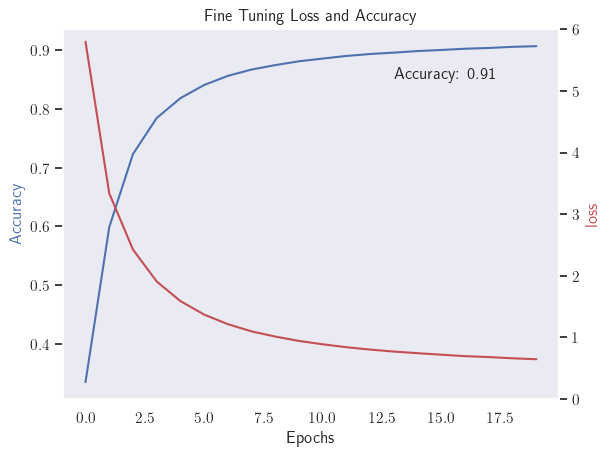

In [ ]:
#| fig-cap: "Fine tuning loss and accuracy"
#| label: fig-fine-tuning

ax = sns.lineplot(fine_plot['accuracy'], color='b')
ax.set_ylabel('Accuracy', color='b')
ax.set_xlabel('Epochs')
ax.text(13, 0.85, s='Accuracy: 0.91')

ax1 = ax.twinx()
sns.lineplot(fine_plot['loss'], color='r', ax=ax1)
ax1.set_ylabel('loss', color='r')
ax1.set_ylim(0,6)

plt.title('Fine Tuning Loss and Accuracy')
plt.show()

In [ ]:
# mlm_model.save('.data/bert_sm_fine_tuned.keras')


---

## Load model and embed

In [ ]:
from keras_hub.api.models import BertBackbone, BertPreprocessor 

BATCH_SIZE = 32

Available device: GPU 



In [ ]:
new_dims = 256

tokenizer = BertPreprocessor.from_preset("bert_small_en_uncased", sequence_length=20)
mlm_model = keras.saving.load_model('.data/bert_sm_fine_tuned.keras')

def extract_embedding_model(mlm_model):
    # Get inputs: token_ids, padding_mask and segment_ids
    mlm_inputs = {inp.name: inp for inp in mlm_model.input}

    # Extract the fine-tuned BERT backbone from mlm_model
    # This is the last layer before the word prediction
    fine_tuned_bert = mlm_model.get_layer("bert_backbone") 
    bert_outputs = fine_tuned_bert(mlm_inputs)
    sequence_output = bert_outputs["sequence_output"]
    projected_output = keras.layers.Dense(new_dims, name="embedding_projection")(sequence_output)
    return keras.Model(inputs=mlm_model.input, outputs=projected_output)

embedding_model = extract_embedding_model(mlm_model)
# embedding_model.summary()

/home/jonux/miniconda3/envs/neural/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 148 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# embedding_model(tokenizer(['hello', 'how are you']))

In [ ]:
data = DataLoader(data_size='large') # 'small'
news_titles = data.news_titles 

In [ ]:
# set masking
token_ids = tokenizer(news_titles)['token_ids'].numpy()
mask = tokenizer(news_titles)['padding_mask'].numpy()

# Mask should exclude CLS and SEP tokens
CLS_TOKEN_ID = tokenizer.tokenizer.cls_token_id  # Typically 101 for BERT
SEP_TOKEN_ID = tokenizer.tokenizer.sep_token_id  # Typically 102 for BERT

special_tokens_mask = (token_ids != CLS_TOKEN_ID) & (token_ids != SEP_TOKEN_ID)
mask = mask & special_tokens_mask  # Combine with standard attention mask

In [ ]:
news_titles = tf.data.Dataset.from_tensor_slices(news_titles).map(tokenizer).batch(512)
embedding_matrix = embedding_model.predict(news_titles)

204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step


In [ ]:
embedding_matrix.shape

(104152, 20, 256)

In [ ]:
print(f"shape: {embedding_matrix.shape}, type: {embedding_matrix.dtype}, size: {embedding_matrix.nbytes / (1024**2):.2f} MB")

shape: (104152, 20, 256), type: float32, size: 2034.22 MB


In [ ]:
np.savez('.data/bert_emb_mask_float32_256d_large.npz', embeddings=embedding_matrix, mask=mask, token_ids=token_ids)

> We can now use this `embedding_matrix` as a convenient lookup layer with the news title indices.

In [ ]:
# Changing to plain zero-masking
import numpy as np
embedding_matrix = np.load('../.data/bert_emb_mask_float32_256d_large.npz')
embeddings = embedding_matrix['embeddings']
token_ids = embedding_matrix['token_ids']
mask = embedding_matrix['token_ids'] != 0
np.savez('../.data/bert_emb_mask_float32_256d_large_mask.npz', embeddings=embeddings, mask=mask, token_ids=token_ids)